# Neural control of a ribbon with Sano's energy, avoiding unstable bifurcations

This notebook is the ribbon counterpart of `neural_control.ipynb` (Tong et al., *Adjoint Learning Through Equilibrium Constraints*, arXiv:2605.03288, multistability task), using the `Sano` constitutive model instead of the plain `DER` rod.

A narrow ribbon is clamped at both ends. A small neural network drives the **left clamp** through a continuation parameter $\tau\in[0,1]$: end-shortening $p_x$, pitch $\beta$ and twist $\vartheta$. At every step the free DOFs are the **equilibrium** $\nabla_x E(x,z)=0$ from `System.solve` (warm-started, so the result is path dependent).

**The problem.** A compressed, twisted ribbon is multistable: the same final clamp pose can be reached on several equilibrium branches (buckled up or down, different twist/writhe). Ramping the controls naively drives the ribbon through an unstable bifurcation, it **snaps**, and ends on the wrong branch. We train the network so that the path

1. ends at a target shape, and
2. stays continuous, i.e. on one stable branch the whole way (no snap).

**Sano's model.** A ribbon has a hard axis 1 and an easy axis 2. Sano's energy couples easy-axis bending and twist with a regularization length $\zeta$:

$$e = e_\text{DER} + \tfrac12 EI_2\,\frac{\tau^4}{\zeta^{-2}+\kappa_2^2}.$$

This coupling is non-convex, which adds to the multistability, and `solve`'s line search handles it. `zeta -> 0` recovers the Kirchhoff rod.

In [1]:
import math, time
import equinox as eqx
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from dismech_jax import Geometry, Material, Sano, make_rod

jax.config.update("jax_enable_x64", True)

## 1. The ribbon and its boundary DOFs

The ribbon lies flat in the $xy$ plane with width along $y$ (`d1`). Bending about the width axis (easy, $EI_2=7.85\times10^{-8}$ N·m², kappa2) is 100x softer than in-plane bending ($EI_1$). No gravity.

We clamp nodes 0, 1 and the last two nodes (including the edge twist DOF). The left clamp is actuated by $(p_x,\beta,\vartheta)$: node 0 moves to $x=p_x$, node 1 sits at $p_x+\Delta\ell\cos\beta$, $z=-\Delta\ell\sin\beta$, and the first edge's twist angle is $\vartheta$. Positive $p_x$ compresses the ribbon.

In [2]:
N, L = 41, 1.0
dl = L / (N - 1)
ZETA = 0.1
geom = Geometry(length=L, r0=1e-3, axs=3.14e-6, ixs1=7.85e-11, ixs2=7.85e-13, jxs=2e-12)  # EA=0.314, EI1=7.85e-6, EI2=7.85e-8
mat = Material(density=1200.0, youngs_rod=1e5, poisson_rod=0.3)
model = Sano.from_legacy(geom, mat, ZETA)

left = np.arange(7)  # node 0 (x,y,z,theta) and node 1 (x,y,z)
right = np.array([4 * (N - 2) + i for i in range(4)] + [4 * (N - 1) + i for i in range(3)])
rod, aux0 = make_rod(geom, mat, N=N, fixed=jnp.asarray(np.concatenate([left, right])),
                     gravity=jnp.zeros(3), model=model)

zpos = {int(d): i for i, d in enumerate(np.asarray(rod.idx_z))}  # position of each DOF in `z`
MID = 4 * (N // 2)  # first DOF of the middle node

def pose_to_zs(pose):
    # pose: (K, 3) = (px, pitch, twist) of the left clamp -> fixed DOFs `zs` (K, n_z)
    px, pitch, tw = pose.T
    zs = jnp.tile(rod.z0, (pose.shape[0], 1))
    zs = zs.at[:, zpos[0]].set(px).at[:, zpos[3]].set(tw)
    return zs.at[:, zpos[4]].set(px + dl * jnp.cos(pitch)).at[:, zpos[6]].set(-dl * jnp.sin(pitch))

def min_eig(xs, zs):
    # smallest eigenvalue of the free-DOF Hessian at every step (>0 <=> stable equilibrium)
    def f(a, xz):
        H, _ = rod.hessian(*xz, a)
        return rod.update(a, *xz), jnp.linalg.eigvalsh(H)[0]
    return jax.lax.scan(f, aux0, (xs, zs))[1]

def diagnose(pose):
    # solve a boundary path and report whether it stays on a stable, converged branch
    zs = pose_to_zs(pose)
    xs, res = rod.solve(zs, aux0, iters=30)
    lam = np.asarray(min_eig(xs, zs))
    bad = (lam < -1e-9) | (np.asarray(res) > 1e-6)
    return dict(xs=xs, zs=zs, q=rod.join(xs, zs), lam=lam, res=np.asarray(res), bad=bad)

def ramp(t, a, b):
    return jnp.clip((t - a) / (b - a), 0.0, 1.0)

## 2. Target shape and the naive path

The target is a **stable, twisted and buckled** equilibrium. We define it with a teacher schedule that first tilts and twists the clamp (which picks the buckling direction) and only then compresses, so every step is a stable equilibrium. The network never sees this schedule, only the target shape.

The naive schedule reaches the **same final clamp pose** but moves all three controls together. It crosses an unstable bifurcation, snaps, and lands on the other buckling branch.

In [3]:
K = 200
tau_t = jnp.linspace(0, 1, K)
FINAL = jnp.array([0.2, 0.3, math.pi])  # final (px, pitch, twist)

teacher = jnp.stack([FINAL[0] * ramp(tau_t, .5, 1), FINAL[1] * ramp(tau_t, 0, .5), FINAL[2] * ramp(tau_t, 0, .5)], 1)
naive = tau_t[:, None] * FINAL

D = {"teacher (target)": diagnose(teacher), "naive linear ramp": diagnose(naive)}
for name, d in D.items():
    print(f"{name:18s} unstable/unconverged steps: {int(d['bad'].sum()):3d}   "
          f"mid-node height z = {float(d['q'][-1, MID + 2]):+.3f}")
q_target = D["teacher (target)"]["q"][-1]

teacher (target)   unstable/unconverged steps:   0   mid-node height z = -0.239
naive linear ramp  unstable/unconverged steps:   8   mid-node height z = +0.201


The loss compares the full final configuration with the target: node positions (scaled by $L$) and the twist angles (with weight 0.1), normalized by the distance between the undeformed ribbon and the target.

In [4]:
def shape_vec(q):
    P = jnp.stack([q[0::4], q[1::4], q[2::4]], 1)
    return jnp.concatenate([P.ravel() / L, 0.1 * q[3::4]])

sv_target = shape_vec(q_target)
scale = jnp.mean((sv_target - shape_vec(rod.q0)) ** 2)

## 3. Neural controller, rollout and loss

The controller is a small MLP $u(\tau)\in\mathbb R^3$ giving the **rates** of $(p_x,\beta,\vartheta)$ (tanh-bounded), integrated over $K=200$ continuation steps. It is initialized to the naive linear ramp, so training starts from the path that snaps. A single `rod.solve` over all steps gives the exact path-dependent gradient with `jax.grad`.

The loss has two parts:

$$\mathcal L=\underbrace{\frac{\|s(q_K)-s^*\|^2}{\|s^*-s_0\|^2}}_{\text{reach the target}}+\lambda\,\underbrace{\frac{K\max_k\|s(q_k)-s(q_{k-1})\|^2}{\|s^*-s_0\|^2}}_{\text{no snap}}$$

where $s$ is the shape vector. A snap is a large jump between consecutive equilibria, so penalizing the largest step pushes the path onto one continuous (stable) branch.

In [5]:
taus = jnp.linspace(0, 1, K + 1)[1:]
u_max = jnp.array([0.5, 1.0, 2 * math.pi])
LAMBDA = 3e-4

net = eqx.nn.MLP(1, 3, 32, 2, activation=jnp.tanh, key=jax.random.PRNGKey(0))
net = eqx.tree_at(lambda n: n.layers[-1].weight, net, net.layers[-1].weight * 0.1)
net = eqx.tree_at(lambda n: n.layers[-1].bias, net, jnp.arctanh(FINAL / u_max))  # start at the naive ramp

def rollout(net):
    u = jax.vmap(lambda t: u_max * jnp.tanh(net(t[None])))(taus)   # boundary rates
    pose = jnp.cumsum(u / K, axis=0)
    zs = pose_to_zs(pose)
    xs, res = rod.solve(zs, aux0, iters=30)                         # equilibrium at each step
    return pose, xs, zs, res

def loss_fn(net):
    pose, xs, zs, res = rollout(net)
    Q = rod.join(xs, zs)
    shape = jnp.mean((shape_vec(Q[-1]) - sv_target) ** 2) / scale
    jumps = jnp.sum(jnp.diff(jax.vmap(shape_vec)(Q), axis=0) ** 2, axis=1)
    snap = K * jnp.max(jumps) / scale
    return shape + LAMBDA * snap, (shape, snap, pose, xs, zs, res)

loss_and_grad = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn, has_aux=True))

## 4. Training (Adam, exact gradients through the equilibrium solves)

In [6]:
def adam_step(params, grads, state, lr=1e-2, b1=0.9, b2=0.999):
    m, v, t = state; t += 1
    m = jax.tree.map(lambda a, g: b1 * a + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda a, g: b2 * a + (1 - b2) * g * g, v, grads)
    step = jax.tree.map(lambda a, b: lr * (a / (1 - b1 ** t)) / (jnp.sqrt(b / (1 - b2 ** t)) + 1e-8), m, v)
    return jax.tree.map(lambda p, s: p - s, params, step), (m, v, t)

params, static = eqx.partition(net, eqx.is_inexact_array)
state = (jax.tree.map(jnp.zeros_like, params), jax.tree.map(jnp.zeros_like, params), 0)
history, t0 = [], time.time()
for it in range(200):
    (loss, (shape, snap, pose, xs, zs, res)), grads = loss_and_grad(eqx.combine(params, static))
    params, state = adam_step(params, eqx.filter(grads, eqx.is_inexact_array), state)
    history.append((float(loss), float(shape), float(snap)))
    if it % 25 == 0:
        print(f"iter {it:3d}  loss {float(loss):.3e}  shape {float(shape):.3e}  snap {float(snap):.1e}  "
              f"max Newton residual {float(res.max()):.1e}  ({time.time()-t0:.0f}s)")
net = eqx.combine(params, static)

iter   0  loss 1.861e+00  shape 1.288e+00  snap 1.9e+03  max Newton residual 5.6e-04  (8s)


iter  25  loss 1.321e-01  shape 1.244e-01  snap 2.6e+01  max Newton residual 2.2e-14  (66s)


iter  50  loss 1.600e-02  shape 7.562e-03  snap 2.8e+01  max Newton residual 2.6e-14  (128s)


iter  75  loss 1.140e-02  shape 3.543e-03  snap 2.6e+01  max Newton residual 1.7e-14  (188s)


iter 100  loss 1.004e-02  shape 2.142e-03  snap 2.6e+01  max Newton residual 2.5e-14  (254s)


iter 125  loss 1.058e-02  shape 3.008e-03  snap 2.5e+01  max Newton residual 3.3e-12  (321s)


iter 150  loss 9.570e-03  shape 2.225e-03  snap 2.4e+01  max Newton residual 7.3e-14  (381s)


iter 175  loss 8.888e-03  shape 1.765e-03  snap 2.4e+01  max Newton residual 1.6e-14  (443s)


## 5. Result: a stable path to the target

In [7]:
pose, *_ = rollout(net)
D["trained controller"] = diagnose(pose)
for name, d in D.items():
    err = float(jnp.mean((shape_vec(d['q'][-1]) - sv_target) ** 2) / scale)
    print(f"{name:20s} unstable/unconverged steps: {int(d['bad'].sum()):3d}   "
          f"mid-node z = {float(d['q'][-1, MID + 2]):+.3f}   relative shape error {err:.2e}   "
          f"final min Hessian eig {d['lam'][-1]:.1e}")

teacher (target)     unstable/unconverged steps:   0   mid-node z = -0.239   relative shape error 0.00e+00   final min Hessian eig 4.3e-08
naive linear ramp    unstable/unconverged steps:   8   mid-node z = +0.201   relative shape error 1.25e+00   final min Hessian eig 3.1e-08
trained controller   unstable/unconverged steps:   0   mid-node z = -0.231   relative shape error 3.17e-03   final min Hessian eig 4.0e-08


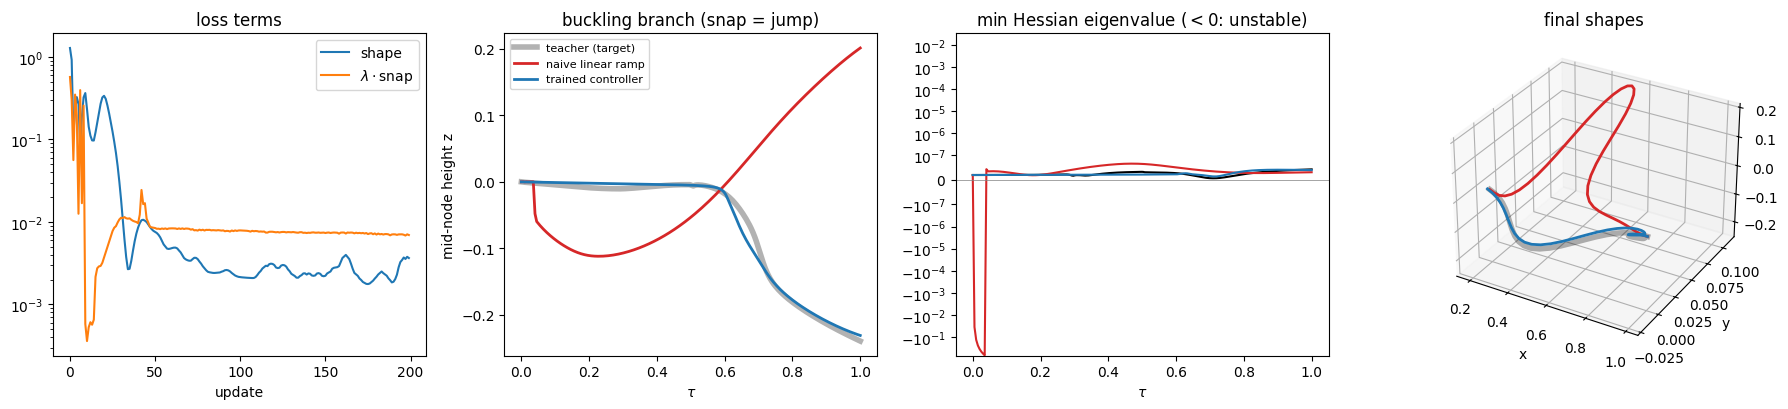

In [8]:
colors = {"teacher (target)": "k", "naive linear ramp": "tab:red", "trained controller": "tab:blue"}
fig = plt.figure(figsize=(18, 4.2))

ax = fig.add_subplot(1, 4, 1)
h = np.array(history)
ax.semilogy(h[:, 1], label="shape"); ax.semilogy(LAMBDA * h[:, 2], label=r"$\lambda\cdot$snap")
ax.set_title("loss terms"); ax.set_xlabel("update"); ax.legend()

ax = fig.add_subplot(1, 4, 2)
for name, d in D.items():
    ax.plot(np.asarray(tau_t), np.asarray(d["q"][:, MID + 2]), color=colors[name], label=name, lw=2 if "teacher" not in name else 4, alpha=1 if "teacher" not in name else .3)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("mid-node height z"); ax.set_title("buckling branch (snap = jump)"); ax.legend(fontsize=8)

ax = fig.add_subplot(1, 4, 3)
for name, d in D.items():
    ax.plot(np.asarray(tau_t), d["lam"], color=colors[name], label=name)
ax.axhline(0, color="gray", lw=.5); ax.set_yscale("symlog", linthresh=1e-7)
ax.set_xlabel(r"$\tau$"); ax.set_title(r"min Hessian eigenvalue ($<0$: unstable)")

ax = fig.add_subplot(1, 4, 4, projection="3d")
for name, d in D.items():
    q = np.asarray(d["q"][-1]); ax.plot(q[0::4], q[1::4], q[2::4], color=colors[name], lw=4 if "teacher" in name else 2, alpha=.3 if "teacher" in name else 1, label=name)
ax.set_title("final shapes"); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout(); plt.show()

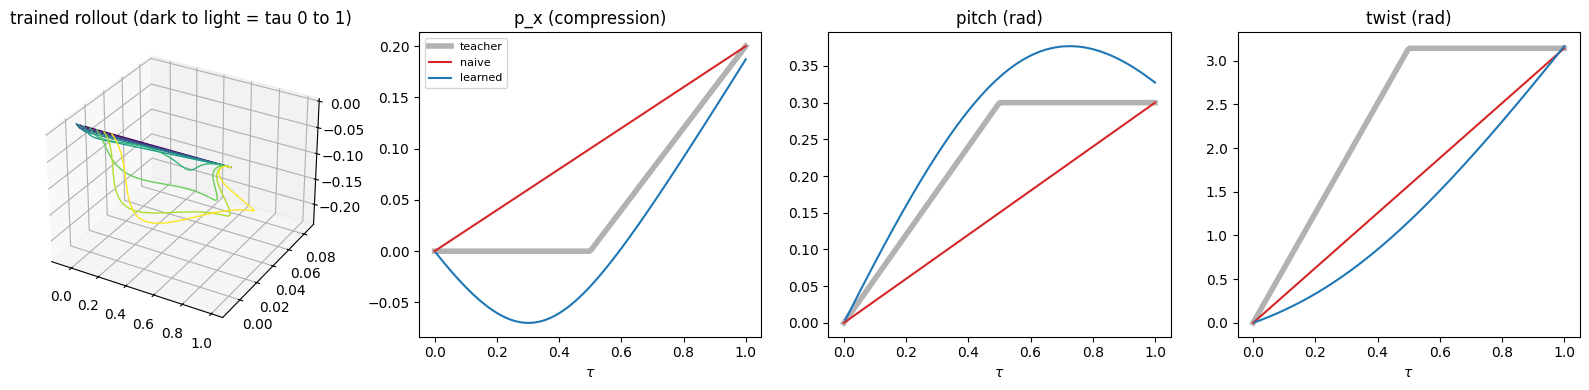

In [9]:
d = D["trained controller"]
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 4, 1, projection="3d")
for k in np.linspace(0, K - 1, 10).astype(int):
    q = np.asarray(d["q"][k]); ax.plot(q[0::4], q[1::4], q[2::4], color=plt.cm.viridis(k / K), lw=1)
ax.set_title("trained rollout (dark to light = tau 0 to 1)")
for i, name in enumerate(["p_x (compression)", "pitch (rad)", "twist (rad)"]):
    ax = fig.add_subplot(1, 4, i + 2)
    ax.plot(np.asarray(tau_t), np.asarray(teacher[:, i]), "k-", lw=4, alpha=.3, label="teacher")
    ax.plot(np.asarray(tau_t), np.asarray(naive[:, i]), color="tab:red", label="naive")
    ax.plot(np.asarray(taus), np.asarray(pose[:, i]), color="tab:blue", label="learned")
    ax.set_title(name); ax.set_xlabel(r"$\tau$")
    if i == 0: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Notes

* **What the network learned.** It starts from the naive ramp, which snaps, and finds a reordering of the controls that keeps every step a stable, converged equilibrium while still ending at the target shape.
* **The continuity term matters.** With $\lambda=0$ the final-shape loss alone reaches the right branch, but the path can still cross unstable steps on the way, which is not a valid quasi-static control. A differentiable snap penalty fixes this without needing Hessian eigenvalues in the loss.
* **Stability check.** A step counts as unstable if the free-DOF Hessian has a negative eigenvalue or Newton did not converge. The trained path should have none.
* **Resolution.** $K=200$ steps are needed so the teacher itself stays on a stable branch. With coarser steps the warm start can jump branches.
* **Exact gradients.** `System.solve` differentiates the whole warm-started rollout through the implicit function theorem, so no adjoint code is needed. Both the Sano coupling and the frame updates are included.